In [8]:
import numpy as np
import pandas as pd
from scipy.ndimage import label

# Загрузка маски (укажи свой путь к файлу)
mask = np.load('/home/nikitachernysh/Storage/Projects/lidar-archaeology-segmentation/thesis/data/raw/Mounds_raster_mask_opened_closed.npy')
# Если маска содержит значения > 1 (разные классы), приводим к бинарному виду
mask_binary = (mask > 0).astype(np.uint8)

# 1. Сегментация объектов
labeled_array, num_features = label(mask_binary)
object_areas = np.bincount(labeled_array.ravel())[1:] # пропускаем фон (индекс 0)

# 2. Определение категорий (в m2, так как 1 пиксель = 1 метр)
# Пороги можно подправить под твои данные
bins = [0, 50, 200, np.inf] 
names = ['Small (<50m²)', 'Medium (50-200m²)', 'Large (>200m²)']

# 3. Группировка
df_objects = pd.DataFrame({'area_m2': object_areas})
df_objects['category'] = pd.cut(df_objects['area_m2'], bins=bins, labels=names)

stats = df_objects.groupby('category').agg(
    count=('area_m2', 'count'),
    total_area_m2=('area_m2', 'sum')
).reset_index()

# Расчет процентов
total_foreground_area = mask_binary.sum()
total_map_area = mask_binary.size

stats['% of All Objects'] = (stats['count'] / num_features * 100).round(2)
stats['% of Foreground Area'] = (stats['total_area_m2'] / total_foreground_area * 100).round(2)
stats['% of Total Map Area'] = (stats['total_area_m2'] / total_map_area * 100).round(6)

print(f"Total objects found: {num_features}")
print(f"Class Imbalance (Foreground vs Background): {total_foreground_area/total_map_area*100:.4f}%")
stats


Total objects found: 4124
Class Imbalance (Foreground vs Background): 0.2700%


,category,count,total_area_m2,% of All Objects,% of Foreground Area,% of Total Map Area
0,Small (<50m²),1491,47756,36.15,10.57,0.028537
1,Medium (50-200m²),2164,211519,52.47,46.81,0.126395
2,Large (>200m²),469,192608,11.37,42.62,0.115094


In [ ]:
# 1. Описательная статистика
desc_stats = df_objects['area_m2'].describe(percentiles=[.1, .25, .5, .75, .9, .95, .99])
df_desc = pd.DataFrame(desc_stats).T.round(2)

# 2. Частотное распределение (гистограмма в виде таблицы)
# Создаем логарифмические или линейные интервалы для распределения
custom_bins = [0, 10, 20, 50, 100, 200, 500, 1000, 5000, np.inf]
df_objects['dist_bins'] = pd.cut(df_objects['area_m2'], bins=custom_bins)

dist_table = df_objects.groupby('dist_bins').agg(
    count=('area_m2', 'count'),
    sum_area=('area_m2', 'sum')
).reset_index()

dist_table['cumulative_%'] = (dist_table['count'].cumsum() / num_features * 100).round(2)

print("Area Summary Statistics (m²):")
display(df_desc)
print("\nFrequency Distribution Table:")
dist_table


Area Summary Statistics (m²):


,count,mean,std,min,10%,25%,50%,75%,90%,95%,99%,max
area_m2,4124.0,109.57,197.71,5.0,24.0,40.0,66.5,120.0,215.0,309.7,666.31,5784.0



Frequency Distribution Table:


,dist_bins,count,sum_area,cumulative_%
0,"(0.0, 10.0]",48,315,1.16
1,"(10.0, 20.0]",221,3624,6.52
2,"(20.0, 50.0]",1222,43817,36.15
3,"(50.0, 100.0]",1306,93305,67.82
4,"(100.0, 200.0]",858,118214,88.63
5,"(200.0, 500.0]",381,109544,97.87
6,"(500.0, 1000.0]",72,48220,99.61
7,"(1000.0, 5000.0]",13,18465,99.93
8,"(5000.0, inf]",3,16379,100.00


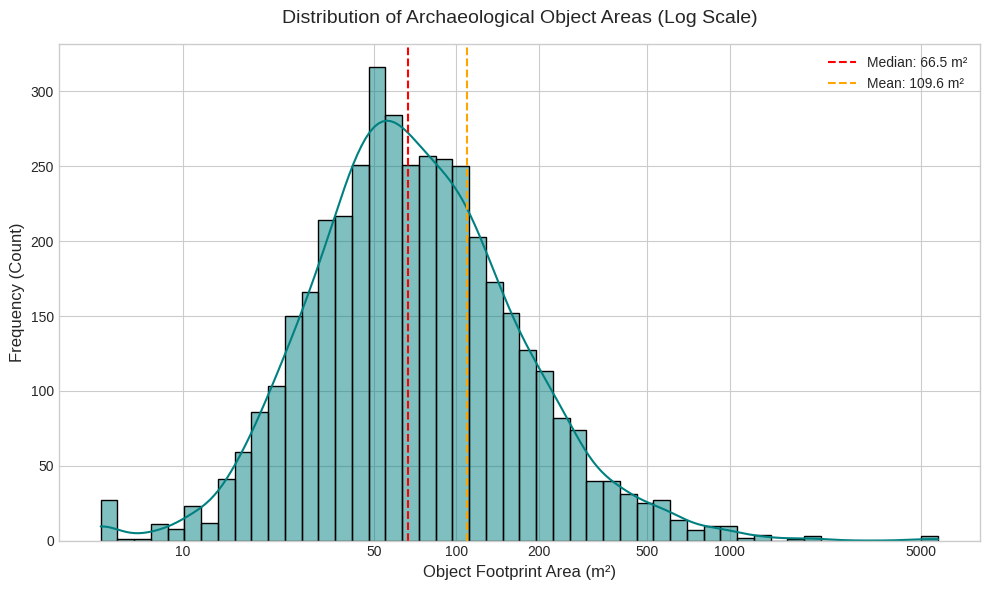

In [5]:
import matplotlib.pyplot as plt
import seaborn as sns

# Настройка стиля для диссертации
plt.style.use('seaborn-v0_8-whitegrid')
fig, ax = plt.subplots(figsize=(10, 6), dpi=100)

# Строим гистограмму с логарифмической шкалой
sns.histplot(df_objects['area_m2'], bins=50, kde=True, log_scale=True, color='teal', ax=ax)

# Добавляем вертикальные линии для медианы и среднего
median_area = df_objects['area_m2'].median()
mean_area = df_objects['area_m2'].mean()

ax.axvline(median_area, color='red', linestyle='--', label=f'Median: {median_area:.1f} m²')
ax.axvline(mean_area, color='orange', linestyle='--', label=f'Mean: {mean_area:.1f} m²')

# Оформление
ax.set_title('Distribution of Archaeological Object Areas (Log Scale)', fontsize=14, pad=15)
ax.set_xlabel('Object Footprint Area (m²)', fontsize=12)
ax.set_ylabel('Frequency (Count)', fontsize=12)
ax.legend()

# Добавим подписи к оси X, чтобы было понятно, что это логарифмы
import matplotlib.ticker as ticker
ax.xaxis.set_major_formatter(ticker.ScalarFormatter())
ax.set_xticks([10, 50, 100, 200, 500, 1000, 5000])

plt.tight_layout()
plt.show()
